# Matching Anomalies to Astronomical Intuition

In [1]:
import os

# Set environment variables to disable multithreading
# as users will probably want to set the number of cores
# to the max of their computer.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import joblib
import time

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

# from sklearn.preprocessing import StandardScaler

from anomaly.constants import GALAXY_LINES
from anomaly.plot import add_line_indicators
from anomaly.plot import spec_photo_thumbnail
from anomaly.utils import specobjid_to_idx

# from anomaly.utils import get_sdss_spec_img
from astroExplain.spectra.notebook import explain_reconstruction_score
from astroExplain.spectra.latent import explain_iforest_score
from astroExplain.spectra.latent import explain_lof_score
from astroExplain.spectra.explanation import TellMeWhy

from autoencoders.ae import AutoEncoder
from sdss.metadata import MetaData

meta = MetaData()

# Custom functions

## Lime weights

In [3]:
def get_weights(
    wave,
    explanation,
    max_normalization=True,
) -> tuple:

    why = TellMeWhy(wave=wave, explanation=explanation)
    weights = why.get_heatmap()

    if max_normalization is True:
        weights = np.abs(weights) / np.nanmax(np.abs(weights))

    return weights

# Config

## LIME constants

In [4]:
fudge_config = {
    "kind_of_fudge": "scale",
    # scale
    "scale_factor": 0.9,
    # control-noise
    "same_noise": True,
    "kernel_size": 3,
    "sigma": 0,
}

## Directories

In [5]:
phd_dir = "/home/elom/phd"
thesis_dir = f"{phd_dir}/thesis"
data_dir = f"{phd_dir}/code"
spectra_dir = f"{data_dir}/spectra"
scores_dir = f"{data_dir}/scores"
models_dir = f"{data_dir}/models"
latent_dir = f"{data_dir}/latent"
ch_5_dir = f"{thesis_dir}/chapters/05_figures"

# Data

In [6]:
wave = np.load(f"{spectra_dir}/wave_spectra_imputed.npy")
wave_nm = wave * 0.1

spectra = np.load(f"{spectra_dir}/spectra_imputed.npy", mmap_mode="r")

final_meta_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop.csv.gz",
    index_col="specobjid",
)

meta_with_ratios_df = pd.read_csv(
    f"{spectra_dir}/final_spec_n_z_warning_drop_with_ratios.csv.gz",
    index_col="specobjid",
)

idx_id_spec = np.load(f"{spectra_dir}/ids_imputing.npy", mmap_mode="r")
bin_id = "bin_03"
latent_arr = np.load(f"{latent_dir}/{bin_id}/latent_{bin_id}.npy", mmap_mode="r")

## N segments

In [ ]:
# n_segments = 150 # Segment width: 25, Last segment width: 23
# n_segments = 110 # Segment width: 34, Last segment width: 33
# n_segments = 163 # Segment width: 23, Last segment width: 24
n_segments = 221  # Segment width: 17, Last segment width: 16
segment_width = wave.shape[0] // n_segments
last_segment_width = wave.shape[0] % n_segments
print(f"Segment width: {segment_width}, Last segment width: {last_segment_width}")

Segment width: 17, Last segment width: 16


## Standard scaler

```python
bin_id = "bin_03"
scaler_model = StandardScaler()

scaler_model.fit(latent_arr)

model_fname = f"standard_scaler_{bin_id}.joblib"

save_path = os.path.join(latent_dir, bin_id, model_fname)
print(f"Saving scaler model to: {save_path}")
joblib.dump(scaler_model, save_path)
```

# Models

In [12]:
bin_id = "bin_03"
# Load VAE
ae_model_03 = AutoEncoder(
    reload=True,
    reload_from=f"{models_dir}/{bin_id}/winner",
)
# Load iForest and LOF
iforest_model_03 = joblib.load(
    f"{latent_dir}/{bin_id}/iforest/iforest_{bin_id}_s128_e300_f100.joblib"
)

lof_model_03 = joblib.load(f"{latent_dir}/{bin_id}/lof/lof_bin_03_n60_manhattan.joblib")
# Load standard scaler
model_fname = f"standard_scaler_{bin_id}.joblib"
scaler_model = joblib.load(f"{latent_dir}/{bin_id}/{model_fname}")

In [13]:
wave.shape

(3773,)

# Residual based anomalies sample

## Data prep

In [19]:
bin_id = "bin_03"

overview_distinct_dict = {
    "SE": 2201231682403592192,
    "Filter SE": 2203468363479410688,
    "Trim SE": 312016418084251648,
    "Filter + Trim SE": 2191010072388200448,
    "RSE": 1534667320067123200,
    "Filter RSE": 2032375840699869184,
    "Trim RSE": 1781231151415846912,
    "Filter + Trim RSE": 2486018670363437056,
}

spec_overview_distinct_dict = {}

print("Get specs and load photometry")

save_to = f"{ch_5_dir}/{bin_id}/res_distinct_xai"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for key in overview_distinct_dict.keys():

    objid = overview_distinct_dict[key]
    spec_idx = specobjid_to_idx(objid, idx_id_spec)

    spec_overview_distinct_dict[key] = spectra[spec_idx]

    # # download image and spectrum
    # ra, dec = final_meta_df[['ra', 'dec']].loc[objid].values
    # get_sdss_spec_img(
    #     specobjid=objid, ra=ra, dec=dec, save_to=save_to
    # )

# Load photometry
img_overview_distinct_dict = {}

for key in overview_distinct_dict.keys():

    objid = overview_distinct_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_overview_distinct_dict[key] = img_

Get specs and load photometry


# SE Explanations

In [24]:
lime_config = {
    "segmentation": "uniform",
    "number_segments": 110,
    # "number_segments": 150,
    "number_samples": 5_000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10_000,
}
score_config = {
    "metric": "mse",
    "velocity": None,
    "relative": False,
    "percentage": None,
    "epsilon": 0.001,
    "lines": list(GALAXY_LINES.keys()),
}

xai_se_dict = {}

for key in overview_distinct_dict.keys():

    specobjid = overview_distinct_dict[key]
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)
    spectrum = spectra[idx_spectrum]

    if key == "SE":
        score_config["velocity"] = 0
        score_config["percentage"] = 100

    elif key == "Filter SE":
        score_config["velocity"] = 250
        score_config["percentage"] = 100

    elif key == "Trim SE":
        score_config["velocity"] = 0
        score_config["percentage"] = 97

    elif key == "Filter + Trim SE":

        score_config["velocity"] = 250
        score_config["percentage"] = 97

    else:
        continue

    explanation, _, _ = explain_reconstruction_score(
        wave=wave,
        spectrum=spectrum,
        score_config=score_config,
        lime_config=lime_config,
        fudge_config=fudge_config,
        model=ae_model_03,
    )

    xai_se_dict[key] = get_weights(
        wave=wave_nm,
        explanation=explanation,
        max_normalization=True,
    )

Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations


## Figure

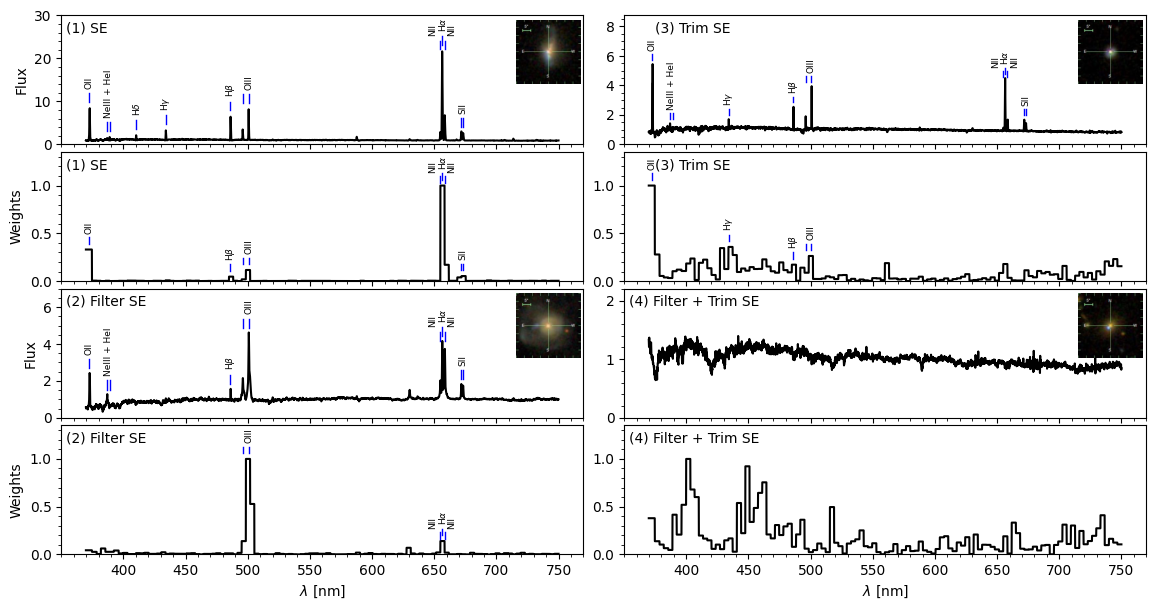

In [25]:
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))

# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "SE": {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 30),
        "yticks": range(0, 31, 10),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "Filter SE": {
        "prefix": "(2)",
        "r": 2,
        "c": 0,
        "ylim": (0, 7),
        "yticks": range(0, 7, 2),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "Trim SE": {
        "prefix": "(3)",
        "r": 0,
        "c": 1,
        "ylim": (0, 8.75),
        "yticks": range(0, 9, 2),
        "text_x": 0.06,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "Filter + Trim SE": {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (0, 2.2),
        "yticks": [0, 1, 2],
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "SE": {
        "top": {
            "indicator_starts": 1.5,
            "indicator_height": 2,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_beta", "OIII", "H_alpha", "SII"],
        },
    },
    "Filter SE": {
        "top": {
            "indicator_starts": 0.25,
            "indicator_height": 0.5,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "NeIII", "H_beta", "OIII", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OIII", "H_alpha"],
        },
    },
    "Trim SE": {
        "top": {
            "indicator_starts": 0.3,
            "indicator_height": 0.4,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_gamma", "H_beta", "OIII"],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for name, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(name, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        spec_overview_distinct_dict[name],
        img_overview_distinct_dict[name],
        add_image=True,
    )
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(
            axs[r, c], wave_nm, spec_overview_distinct_dict[name], **top_lines
        )

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(axs[r + 1, c], wave_nm, xai_se_dict[name])
    axs[r + 1, c].set_ylim(0, 1.35)
    axs[r + 1, c].set_yticks([0, 0.5, 1])
    axs[r + 1, c].minorticks_on()
    axs[r + 1, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r + 1, c].transAxes,
    )

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(axs[r + 1, c], wave_nm, xai_se_dict[name], **bot_lines)

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[3, col].set_xlim(350, 770)
    axs[3, col].set_xticks(wave_ticks)
    axs[3, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)

# RSE explanations

In [26]:
lime_config = {
    "segmentation": "uniform",
    "number_segments": 110,
    # "number_segments": 150,
    "number_samples": 5_000,
    "batch_size": 100,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10_000,
}
score_config = {
    "metric": "mse",
    "velocity": None,
    "relative": True,
    "percentage": None,
    "epsilon": 0.001,
    "lines": list(GALAXY_LINES.keys()),
}

xai_rse_dict = {}

for key in overview_distinct_dict.keys():

    specobjid = overview_distinct_dict[key]
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)
    spectrum = spectra[idx_spectrum]

    if key == "RSE":
        score_config["velocity"] = 0
        score_config["percentage"] = 100

    elif key == "Filter RSE":
        score_config["velocity"] = 250
        score_config["percentage"] = 100

    elif key == "Trim RSE":
        score_config["velocity"] = 0
        score_config["percentage"] = 97

    elif key == "Filter + Trim RSE":

        score_config["velocity"] = 250
        score_config["percentage"] = 97
    else:
        continue

    explanation, _, _ = explain_reconstruction_score(
        wave=wave,
        spectrum=spectrum,
        score_config=score_config,
        lime_config=lime_config,
        fudge_config=fudge_config,
        model=ae_model_03,
    )

    xai_rse_dict[key] = get_weights(
        wave=wave_nm,
        explanation=explanation,
        max_normalization=True,
    )

Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations


## Figure

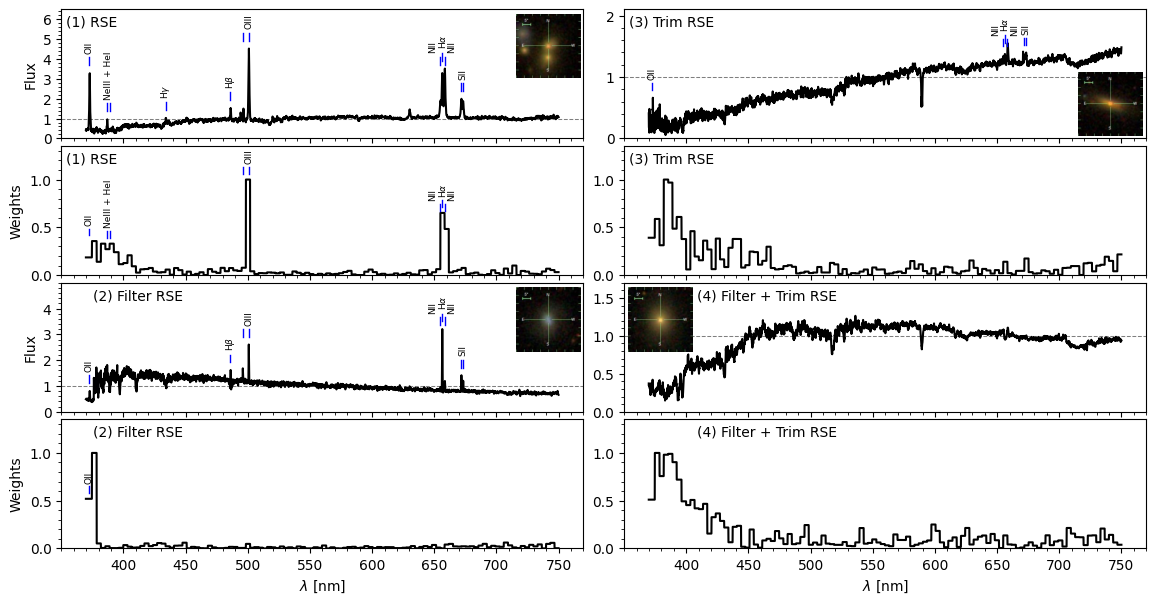

In [27]:
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))

# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# Added text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "RSE": {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (0, 6.5),
        "yticks": range(0, 7, 1),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "Filter RSE": {
        "prefix": "(2)",
        "r": 2,
        "c": 0,
        "ylim": (0, 5),
        "yticks": range(0, 5, 1),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.06,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "Trim RSE": {
        "prefix": "(3)",
        "r": 0,
        "c": 1,
        "ylim": (0, 2.1),
        "yticks": range(0, 3, 1),
        "bbox_to_anchor": (0.695, 0.07, 0.5, 0.5),
        "text_x": 0.01,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
    "Filter + Trim RSE": {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (0, 1.7),
        "yticks": [0, 0.5, 1, 1.5],
        "bbox_to_anchor": (-0.167, 0.52, 0.5, 0.5),
        "text_x": 0.14,
        "text_y": 0.9,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "RSE": {
        "top": {
            "indicator_starts": 0.4,
            "indicator_height": 0.4,
            "delta": 10,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 6,
            "fontsize": 6.5,
            "active_lines": ["OII", "NeIII", "OIII", "H_alpha"],
        },
    },
    "Filter RSE": {
        "top": {
            "indicator_starts": 0.3,
            "indicator_height": 0.3,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_beta", "OIII", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII"],
        },
    },
    "Trim RSE": {
        "top": {
            "indicator_starts": 0.12,
            "indicator_height": 0.12,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_alpha", "SII"],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for name, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    bbox_to_anchor = p_conf["bbox_to_anchor"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(name, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        spec_overview_distinct_dict[name],
        img_overview_distinct_dict[name],
        add_image=True,
        bbox_to_anchor=bbox_to_anchor,
    )
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].axhline(
        y=1, color="black", linestyle="--", linewidth=0.75, zorder=5, alpha=0.5
    )
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(
            axs[r, c], wave_nm, spec_overview_distinct_dict[name], **top_lines
        )

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(axs[r + 1, c], wave_nm, xai_rse_dict[name])
    axs[r + 1, c].set_ylim(0, 1.35)
    axs[r + 1, c].set_yticks([0, 0.5, 1])
    axs[r + 1, c].minorticks_on()
    axs[r + 1, c].text(
        text_x,
        text_y,
        f"{prefix} {name}",
        ha=ha,
        va=va,
        transform=axs[r + 1, c].transAxes,
    )

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(axs[r + 1, c], wave_nm, xai_rse_dict[name], **bot_lines)

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[3, col].set_xlim(350, 770)
    axs[3, col].set_xticks(wave_ticks)
    axs[3, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)

# iForest Explanations

## Data prep

In [28]:
bin_id = "bin_03"

iforest_dict = {
    "oiii_mgrt_h_alpha": 1928785351883646976,
    "oiii_sim_h_alpha_no_oii": 749873288389355520,
    "oiii_sim_h_alpha": 2390364730700097536,
    "h_alpha_grt_oiii": 694769887481980928,
}

spec_iforest_dict = {}

print("Get specs and load photometry")

save_to = f"{ch_5_dir}/{bin_id}/latent_xai/iforest"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for key in iforest_dict.keys():

    objid = iforest_dict[key]
    spec_idx = specobjid_to_idx(objid, idx_id_spec)

    spec_iforest_dict[key] = spectra[spec_idx]

    # # download image and spectrum
    # ra, dec = final_meta_df[["ra", "dec"]].loc[objid].values
    # get_sdss_spec_img(specobjid=objid, ra=ra, dec=dec, save_to=save_to)

# Load photometry
img_iforest_dict = {}

for key in iforest_dict.keys():

    objid = iforest_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_iforest_dict[key] = img_

Get specs and load photometry


## Explanations

In [32]:
xai_iforest_dict = {}

lime_config = {
    "segmentation": "uniform",
    "number_segments": 110,
    # "number_segments": 150,
    "number_samples": 10_000,
    "batch_size": 250,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10_000,
}

start_time = time.perf_counter()

for key in iforest_dict.keys():

    specobjid = iforest_dict[key]
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)
    spectrum = spectra[idx_spectrum]

    explanation, _, _ = explain_iforest_score(
        spectrum=spectrum,
        lime_config=lime_config,
        fudge_config=fudge_config,
        encoder=ae_model_03.encode,
        iforest_model=iforest_model_03,
        fitted_scaler=scaler_model,
    )

    xai_iforest_dict[key] = get_weights(
        wave=wave_nm,
        explanation=explanation,
        max_normalization=True,
    )
end_time = time.perf_counter()
print(f"Trained LOF model for {bin_id} " f"in {end_time - start_time:.2f} seconds.")

Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Trained LOF model for bin_03 in 25.80 seconds.


## Figure

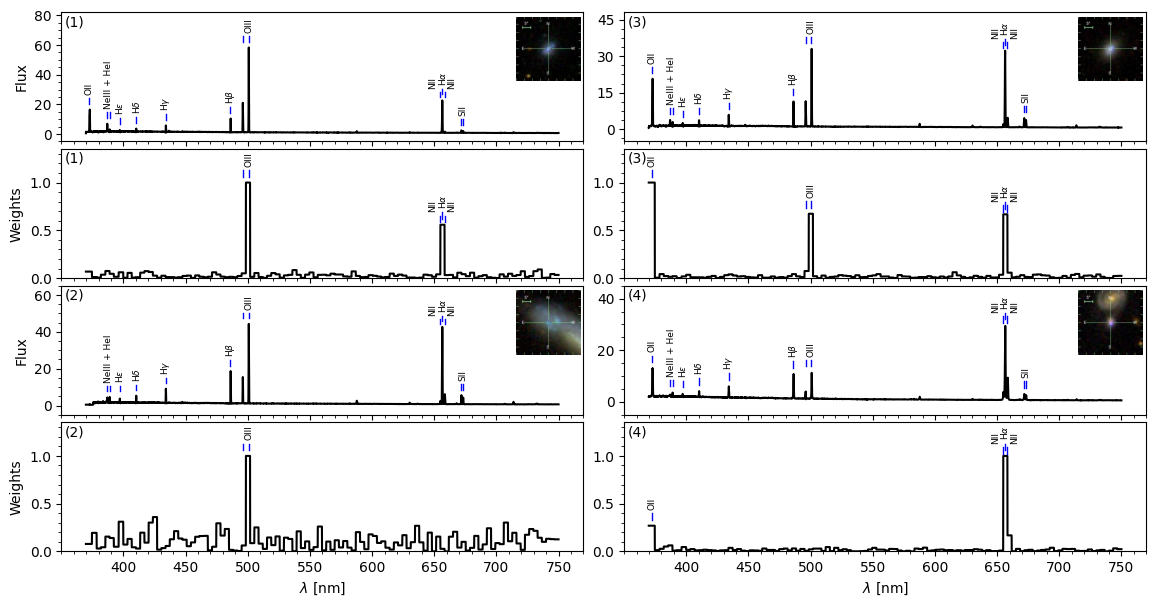

In [33]:
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))

# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# Added text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "oiii_mgrt_h_alpha": {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (-5, 82),
        "yticks": range(0, 85, 20),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "oiii_sim_h_alpha_no_oii": {
        "prefix": "(2)",
        "r": 2,
        "c": 0,
        "ylim": (-5, 65),
        "yticks": range(0, 61, 20),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "oiii_sim_h_alpha": {
        "prefix": "(3)",
        "r": 0,
        "c": 1,
        "ylim": (-5, 48),
        "yticks": range(0, 46, 15),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "h_alpha_grt_oiii": {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (-5, 45),
        "yticks": range(0, 41, 20),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
}

# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "oiii_mgrt_h_alpha": {
        "top": {
            "indicator_starts": 4,
            "indicator_height": 4,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_epsilon",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 6,
            "fontsize": 6.5,
            "active_lines": ["OIII", "H_alpha"],
        },
    },
    "oiii_sim_h_alpha_no_oii": {
        "top": {
            "indicator_starts": 3,
            "indicator_height": 3,
            "delta": 10,
            "fontsize": 6.5,
            "active_lines": [
                "NeIII",
                "H_epsilon",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 6,
            "fontsize": 6.5,
            "active_lines": ["OIII"],
        },
    },
    "oiii_sim_h_alpha": {
        "top": {
            "indicator_starts": 2.5,
            "indicator_height": 2.5,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_epsilon",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "OIII", "H_alpha"],
        },
    },
    "h_alpha_grt_oiii": {
        "top": {
            "indicator_starts": 2.5,
            "indicator_height": 2.5,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_epsilon",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_alpha"],
        },
    },
}

# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------

for name, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    bbox_to_anchor = p_conf["bbox_to_anchor"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(name, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        spec_iforest_dict[name],
        img_iforest_dict[name],
        add_image=True,
        bbox_to_anchor=bbox_to_anchor,
    )
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, spec_iforest_dict[name], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(
        axs[r + 1, c], wave_nm, xai_iforest_dict[name]
    )
    axs[r + 1, c].set_ylim(0, 1.35)
    axs[r + 1, c].set_yticks([0, 0.5, 1])
    axs[r + 1, c].minorticks_on()
    axs[r + 1, c].text(
        text_x,
        text_y,
        f"{prefix}",
        ha=ha,
        va=va,
        transform=axs[r + 1, c].transAxes,
    )

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(axs[r + 1, c], wave_nm, xai_iforest_dict[name], **bot_lines)

# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[3, col].set_xlim(350, 770)
    axs[3, col].set_xticks(wave_ticks)
    axs[3, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)

# LOF Explanations

## Data prep

In [34]:
bin_id = "bin_03"

lof_dict = {
    "evolved_H_alpha": 2501842015717713920,
    "evolved_sf": 873872364331362304,
    "weird_blue_excess": 3243851847563241472,
    "emission_line": 656537668875741184,
}

spec_lof_dict = {}

print("Get specs and load photometry")

save_to = f"{ch_5_dir}/{bin_id}/latent_xai/lof"

if not os.path.exists(save_to):
    os.makedirs(save_to)

for key in lof_dict.keys():

    objid = lof_dict[key]
    spec_idx = specobjid_to_idx(objid, idx_id_spec)

    spec_lof_dict[key] = spectra[spec_idx]

    # # download image and spectrum
    # ra, dec = final_meta_df[["ra", "dec"]].loc[objid].values
    # get_sdss_spec_img(specobjid=objid, ra=ra, dec=dec, save_to=save_to)

# Load photometry
img_lof_dict = {}

for key in lof_dict.keys():

    objid = lof_dict[key]
    img_name = f"image_{objid}.jpeg"
    img_ = mpimg.imread(f"{save_to}/{img_name}")
    img_lof_dict[key] = img_

Get specs and load photometry


## Explanations

In [53]:
xai_lof_dict = {}

lime_config = {
    "segmentation": "uniform",
    # "number_segments": 81,
    "number_segments": 110,
    # "number_segments": 150,
    "number_samples": 25_000,
    "batch_size": 2_500,
    "progress_bar": False,
    "distance_metric": "cosine",
    "number_features": 10_000,
}

start_time = time.perf_counter()

for key in lof_dict.keys():

    specobjid = lof_dict[key]
    idx_spectrum = specobjid_to_idx(specobjid, idx_id_spec)
    spectrum = spectra[idx_spectrum]

    explanation, _, _ = explain_lof_score(
        spectrum=spectrum,
        lime_config=lime_config,
        fudge_config=fudge_config,
        encoder=ae_model_03.encode,
        lof_model=lof_model_03,
        fitted_scaler=scaler_model,
    )

    xai_lof_dict[key] = get_weights(
        wave=wave_nm,
        explanation=explanation,
        max_normalization=True,
    )
end_time = time.perf_counter()
print(f"Trained LOF model for {bin_id} " f"in {end_time - start_time:.2f} seconds.")

Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Set explainer and Get explanations
Trained LOF model for bin_03 in 290.19 seconds.


## Figure

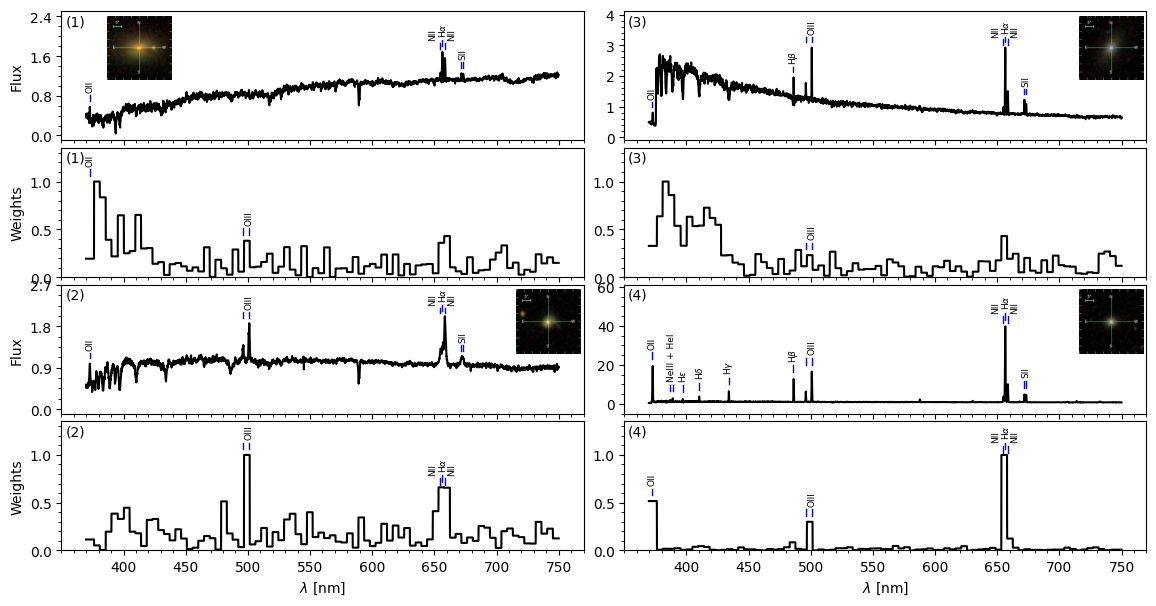

In [52]:
fig, axs = plt.subplots(4, 2, sharex=True, figsize=(14, 7))
# -------------------------------------------------------------------------------------
# 1. Panel Layout Configuration (Dictionary)
# Added text_x and text_y for independent positioning per panel
# -------------------------------------------------------------------------------------
panels = {
    "evolved_H_alpha": {
        "prefix": "(1)",
        "r": 0,
        "c": 0,
        "ylim": (-0.1, 2.5),
        "yticks": [0, 0.8, 1.6, 2.4],
        "bbox_to_anchor": (-0.088, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "evolved_sf": {
        "prefix": "(2)",
        "r": 2,
        "c": 0,
        "ylim": (-0.1, 2.5),
        "yticks": [0, 0.9, 1.8, 2.7],
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "weird_blue_excess": {
        "prefix": "(3)",
        "r": 0,
        "c": 1,
        "ylim": (-0.1, 4.1),
        "yticks": range(0, 5, 1),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
    "emission_line": {
        "prefix": "(4)",
        "r": 2,
        "c": 1,
        "ylim": (-5, 61),
        "yticks": range(0, 65, 20),
        "bbox_to_anchor": (0.695, 0.52, 0.5, 0.5),
        "text_x": 0.0075,
        "text_y": 0.925,
        "ha": "left",
        "va": "center",
    },
}
# -------------------------------------------------------------------------------------
# 2. Line Indicator Configuration
# -------------------------------------------------------------------------------------
line_configs = {
    "evolved_H_alpha": {
        "top": {
            "indicator_starts": 0.12,
            "indicator_height": 0.12,
            "delta": 1,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 6,
            "fontsize": 6.5,
            "active_lines": ["OII", "OIII"],
        },
    },
    "evolved_sf": {
        "top": {
            "indicator_starts": 0.12,
            "indicator_height": 0.12,
            "delta": 10,
            "fontsize": 6.5,
            "active_lines": ["OII", "OIII", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 6,
            "fontsize": 6.5,
            "active_lines": ["OIII", "H_alpha"],
        },
    },
    "weird_blue_excess": {
        "top": {
            "indicator_starts": 0.175,
            "indicator_height": 0.175,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "H_beta", "OIII", "H_alpha", "SII"],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OIII"],
        },
    },
    "emission_line": {
        "top": {
            "indicator_starts": 3.5,
            "indicator_height": 3.5,
            "delta": 5,
            "fontsize": 6.5,
            "active_lines": [
                "OII",
                "NeIII",
                "H_epsilon",
                "H_delta",
                "H_gamma",
                "H_beta",
                "OIII",
                "H_alpha",
                "SII",
            ],
        },
        "bot": {
            "indicator_starts": 0.06,
            "indicator_height": 0.07,
            "delta": 2,
            "fontsize": 6.5,
            "active_lines": ["OII", "OIII", "H_alpha"],
        },
    },
}
# -------------------------------------------------------------------------------------
# 3. Main Plotting Loop
# -------------------------------------------------------------------------------------
for name, p_conf in panels.items():

    # Panel variables
    prefix, r, c = p_conf["prefix"], p_conf["r"], p_conf["c"]
    ylim, yticks = p_conf["ylim"], p_conf["yticks"]
    bbox_to_anchor = p_conf["bbox_to_anchor"]
    text_x, text_y = p_conf["text_x"], p_conf["text_y"]
    ha, va = p_conf["ha"], p_conf["va"]

    # Line configs for panel (default to empty dicts if none exist)
    configs = line_configs.get(name, {})
    top_lines = configs.get("top", {})
    bot_lines = configs.get("bot", {})

    # --- Top Plot: Spec + Thumbnail ---
    axs[r, c], _ = spec_photo_thumbnail(
        axs[r, c],
        wave_nm,
        spec_lof_dict[name],
        img_lof_dict[name],
        add_image=True,
        bbox_to_anchor=bbox_to_anchor,
    )
    axs[r, c].set_ylim(ylim)
    axs[r, c].set_yticks(yticks)
    axs[r, c].minorticks_on()
    axs[r, c].text(
        text_x,
        text_y,
        f"{prefix}",
        ha=ha,
        va=va,
        transform=axs[r, c].transAxes,
    )

    if c == 0:
        axs[r, c].set_ylabel("Flux")

    # Add line indicators
    if top_lines.get("active_lines"):
        add_line_indicators(axs[r, c], wave_nm, spec_lof_dict[name], **top_lines)

    # --- Bottom Plot: Explanation Weights ---
    axs[r + 1, c], _ = spec_photo_thumbnail(axs[r + 1, c], wave_nm, xai_lof_dict[name])
    axs[r + 1, c].set_ylim(0, 1.35)
    axs[r + 1, c].set_yticks([0, 0.5, 1])
    axs[r + 1, c].minorticks_on()
    axs[r + 1, c].text(
        text_x,
        text_y,
        f"{prefix}",
        ha=ha,
        va=va,
        transform=axs[r + 1, c].transAxes,
    )

    if c == 0:
        axs[r + 1, c].set_ylabel("Weights")

    # Add line indicators
    if bot_lines.get("active_lines"):
        add_line_indicators(axs[r + 1, c], wave_nm, xai_lof_dict[name], **bot_lines)
# -------------------------------------------------------------------------------------
# 4. Global Axes Settings (Bottom Row)
# -------------------------------------------------------------------------------------
wave_ticks = list(np.arange(400, 751, 50))
for col in [0, 1]:
    axs[3, col].set_xlim(350, 770)
    axs[3, col].set_xticks(wave_ticks)
    axs[3, col].set_xlabel(r"$\lambda$ [nm]")

plt.subplots_adjust(hspace=0.06, wspace=0.078)